<a href="https://colab.research.google.com/github/mayzeAnjos/Marketing_DataSet/blob/main/Projeto_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Previsão de Subscrição de Depósito a Prazo em Campanhas de Marketing Bancário

In [ ]:
# biblioteca para acessar o dataset da UCI
!pip install ucimlrepo

# importando as bibliotecas
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

# carregando o dataset
bank_marketing = fetch_ucirepo(id=222)

# separando features (X) e target (y)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# juntando tudo em um único DataFrame para facilitar a análise
df = pd.concat([X, y], axis=1)

# visualizando as primeiras linhas
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


(**OBS**: Os dados foram carregados diretamente do repositório UCI Machine Learning (dataset ID 222 - Bank Marketing), utilizando a biblioteca `ucimlrepo`. Isso garante que o notebook seja executável em qualquer ambiente, sem necessidade de download manual de arquivos.)

## Seção 5.1: Identificação e descrição do problema

**Título do Projeto:**
Previsão de Subscrição de Depósito a Prazo em Campanhas de Marketing Bancário

**Definição da Tarefa:**
- **Atributo-alvo:** A variável `y`, que indica se o cliente subscreveu (1 = "yes") ou não (0 = "no") um depósito a prazo.
- **Atributos Preditivos:** Todas as demais variáveis do dataset (idade, profissão, saldo, tipo de contato, etc.).
- **Tipo de problema:** Classificação Binária, pois o objetivo é prever uma categoria com duas classes possíveis.
- **Objetivo da aplicação:** Construir um modelo que auxilie a instituição bancária a identificar clientes com maior propensão a adquirir o produto, otimizando assim as campanhas de marketing.

**Justificativa:** Este é um problema clássico de marketing direto, onde prever o comportamento do cliente pode reduzir custos e aumentar a eficiência das campanhas telefônicas.

## Seção 5.2: Compreensão dos dados

In [ ]:
# 1. Quantidade de clientes (registros) e colunas (atributos)
print(f"O dataset possui {df.shape[0]} clientes e {df.shape[1]} colunas.")

# 2. Tipos das variáveis e visão geral
print("\n===== Tipos de dados por coluna =====\n")
print(df.dtypes)

print("\n=============== Resumo estatístico das variáveis numéricas ===============\n")
display(df.describe())

print("\n===== Informações gerais do DataFrame =====\n")
df.info()

O dataset possui 45211 clientes e 17 colunas.

===== Tipos de dados por coluna =====

age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
y              object
dtype: object

=============== Resumo estatístico das variáveis numéricas ===============



,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000



===== Informações gerais do DataFrame =====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


O dataset possui 45.211 registros e 17 colunas e as variáveis são uma mistura de tipos numéricos (int64) e categóricos (object).

As variáveis numéricas como `age` e `balance` apresentam médias e desvios padrão que sugerem o nível de suas dispersões: A variável `age` apresenta baixa dispersão (std = 10,62), com clientes concentrados entre 30 e 52 anos; Já `balance` mostra alta dispersão (std = 3.044,77) e presença de outliers com saldos muito elevados, sugerindo a necessidade de transformação logarítmica ou tratamento de valores extremos.

A variável `duration` (duração da chamada) apresenta alta variabilidade (std = 257,5), com chamadas de 0 a 4.918 segundos. Embora seja um forte preditor, ela pode causar vazamento de dados (data leakage), pois a duração só é conhecida após o contato. Isso será discutido no pré-processamento.

As variáveis categóricas incluem `job`, `marital`, `education`, etc., que precisarão ser codificadas numericamente para que os algoritmos de Machine Learning possam entendê-las e consigam trabalhar.

In [ ]:
# 3. Verificar valores ausentes
print("=== Valores ausentes por coluna ===\n")
print(df.isnull().sum())

# 4. Verificar duplicatas
print(f"\nNúmero de linhas duplicadas: {df.duplicated().sum()}")

=== Valores ausentes por coluna ===

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64

Número de linhas duplicadas: 0


Contrariando a informação inicial da documentação, a análise revelou valores ausentes em algumas variáveis. As colunas `job` (288 ausentes), `education` (1.857 ausentes) e `contact` (13.020 ausentes) apresentam dados faltantes, enquanto `poutcome` possui 36.959 valores ausentes, o que representa 81,7% dos registros. Isso ocorre porque o dataset utiliza *'unknown'* para representar informações não disponíveis, o que é comum em campanhas de marketing. Esses valores deverão ser tratados no pré-processamento.


=== Distribuição da variável 'y' (subscrição) ===

y
no     39922
yes     5289
Name: count, dtype: int64

Proporção:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64



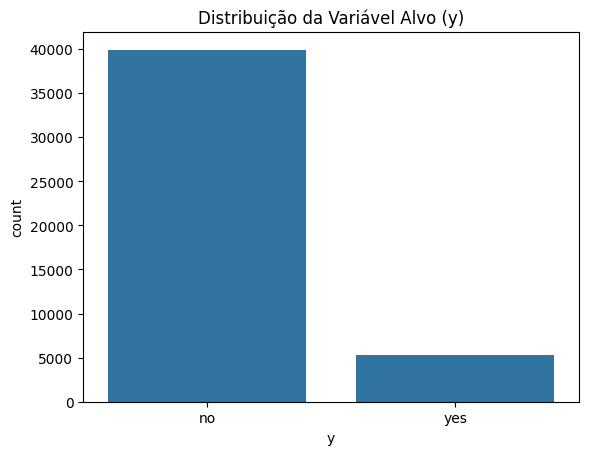

In [ ]:
# 5. Distribuição da variável alvo
print("\n=== Distribuição da variável 'y' (subscrição) ===\n")
print(df['y'].value_counts())
print(f"\nProporção:\n{df['y'].value_counts(normalize=True) * 100}\n")

# Visualizando em um gráfico de barras
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='y', data=df)
plt.title('Distribuição da Variável Alvo (y)')
plt.show()

A variável y está desbalanceada. Apenas 11,7% (aproximadamente) dos clientes subscreveram o depósito (yes), enquanto cerca de 88,3% não subscreveram (no). Esse desbalanceamento é comum em campanhas de marketing e deverá ser tratado durante o pré-processamento (por exemplo, com técnicas de balanceamento como SMOTE) ou considerado na escolha das métricas de avaliação (priorizando F1-score em vez de acurácia).

In [ ]:
# Verificando valores únicos em variáveis categóricas para identificar possíveis inconsistências
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\nValores únicos em '{col}':\n")
    print(df[col].unique())

# Verificar se pdays = -1 realmente significa "não contatado anteriormente"
print("\n\n=== Verificação da variável pdays ===\n")
print(df['pdays'].value_counts().sort_index().head(10))


Valores únicos em 'job':

['management' 'technician' 'entrepreneur' 'blue-collar' nan 'retired'
 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid' 'student']

Valores únicos em 'marital':

['married' 'single' 'divorced']

Valores únicos em 'education':

['tertiary' 'secondary' nan 'primary']

Valores únicos em 'default':

['no' 'yes']

Valores únicos em 'housing':

['yes' 'no']

Valores únicos em 'loan':

['no' 'yes']

Valores únicos em 'contact':

[nan 'cellular' 'telephone']

Valores únicos em 'month':

['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

Valores únicos em 'poutcome':

[nan 'failure' 'other' 'success']

Valores únicos em 'y':

['no' 'yes']


=== Verificação da variável pdays ===

pdays
-1    36954
 1       15
 2       37
 3        1
 4        2
 5       11
 6       10
 7        7
 8       25
 9       12
Name: count, dtype: int64


A variável pdays apresenta um comportamento peculiar: o valor -1, que representa clientes que nunca foram contatados em campanhas anteriores, aparece em 36.954 registros (81,7% do total). Apenas os valores positivos (1 a 9 dias) representam os clientes que já haviam sido contatados. Isso indica que a maioria dos clientes é nova na base de dados, o que é consistente com a natureza de campanhas de marketing. Esse padrão deve ser considerado no pré-processamento, pois -1 não é um valor numérico comum, mas sim uma categoria especial.

## 5.3 Análise exploratória

Nesta etapa, analisamos visualmente algumas características importantes do conjunto de dados para entender melhor o perfil dos clientes antes de aplicar os tratamentos.

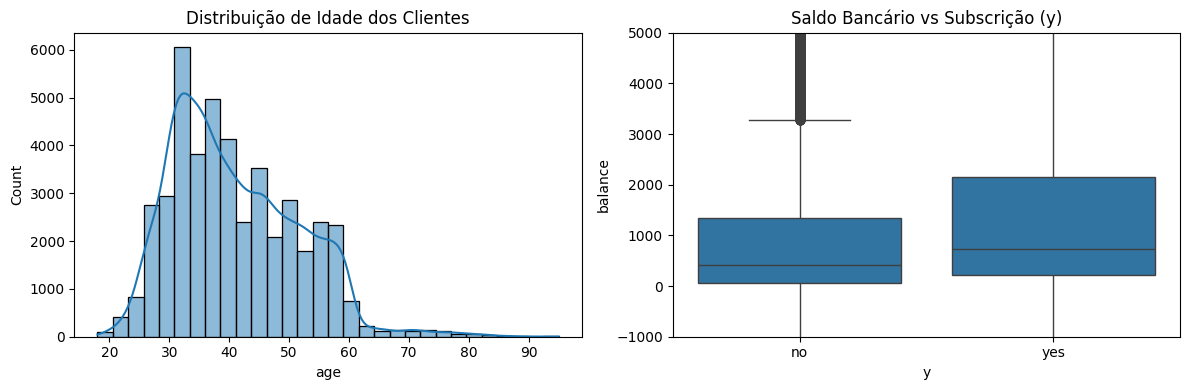

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Idade
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Idade dos Clientes')

# Gráfico 2: Saldo bancário (limitado para melhor visualização devido a outliers)
sns.boxplot(x='y', y='balance', data=df, ax=axes[1])
axes[1].set_ylim(-1000, 5000)
axes[1].set_title('Saldo Bancário vs Subscrição (y)')

plt.tight_layout()
plt.show()

**Interpretação:** O histograma mostra que a maioria dos contatados tem entre 30 e 40 anos. O boxplot revela que clientes que subscreveram (yes) tendem a ter um saldo bancário ligeiramente maior e menos concentrado no zero, além de confirmar a forte presença de outliers no atributo `balance`.

## 5.4 Pré-processamento

Identificamos e tratamos os seguintes problemas nos dados:
1. **Valores Ausentes:** A string 'unknown' foi substituída por `NaN` e preenchida com a moda da respectiva coluna categórica, pois é a técnica mais segura para manter a distribuição original sem perder registros.
2. **Atributos Irrelevantes/Vazamento:** A coluna `duration` foi removida para evitar vazamento de dados (*data leakage*), pois a duração da chamada só é conhecida após o contato. A coluna `pdays` foi transformada em uma variável binária `contatado_antes`.
3. **Escalonamento e Encoding:** Aplicamos `OneHotEncoder` nas variáveis categóricas para transformá-las em números e `StandardScaler` nas numéricas para evitar que variáveis com valores muito altos (como `balance`) dominem o modelo.


In [ ]:
# 1. Substituir 'unknown' por NaN
df = df.replace('unknown', np.nan)

# 2. Tratar nulos categóricos criando categoria própria
colunas_categoricas_nulas = ['job', 'education', 'contact', 'poutcome']
for col in colunas_categoricas_nulas:
    df[col] = df[col].fillna('Nao_Informado')

# 3. Remover duration (data leakage)
df = df.drop(columns=['duration'])

# 4. Criar variável binária a partir de pdays
df['contatado_antes'] = np.where(df['pdays'] == -1, 0, 1)

print(df[colunas_categoricas_nulas + ['contatado_antes']].head())
print(df.isnull().sum())

             job      education        contact       poutcome  contatado_antes
0     management       tertiary  Nao_Informado  Nao_Informado                0
1     technician      secondary  Nao_Informado  Nao_Informado                0
2   entrepreneur      secondary  Nao_Informado  Nao_Informado                0
3    blue-collar  Nao_Informado  Nao_Informado  Nao_Informado                0
4  Nao_Informado  Nao_Informado  Nao_Informado  Nao_Informado                0
age                0
job                0
marital            0
education          0
default            0
balance            0
housing            0
loan               0
contact            0
day_of_week        0
month              0
campaign           0
pdays              0
previous           0
poutcome           0
y                  0
contatado_antes    0
dtype: int64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

# 1. Separar X e y, mapear target para 1/0
X = df.drop(columns=['y'])
y = df['y'].map({'yes': 1, 'no': 0})

# 2. Definir os grupos de colunas
colunas_categoricas = X.select_dtypes(include='object').columns.tolist()

# balance vai separado por causa dos outliers
coluna_outlier = ['balance']
colunas_numericas = X.select_dtypes(include=np.number).columns.tolist()
colunas_numericas = [col for col in colunas_numericas if col not in coluna_outlier]

print("Categóricas:", colunas_categoricas)
print("Numéricas (StandardScaler):", colunas_numericas)
print("Numérica com outliers (RobustScaler):", coluna_outlier)

# 3. Montar o ColumnTransformer
preprocessador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), colunas_categoricas),
        ('num', StandardScaler(), colunas_numericas),
        ('num_outlier', RobustScaler(), coluna_outlier)
    ]
)

# Aplicar
X_processed = preprocessador.fit_transform(X)

print(X_processed.shape)

Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numéricas (StandardScaler): ['age', 'day_of_week', 'campaign', 'pdays', 'previous', 'contatado_antes']
Numérica com outliers (RobustScaler): ['balance']
(45211, 42)


#
#
# Etapa 3 - Divisão em Treino/Teste e Balanceamento com SMOTE
# Objetivo: separar treino e teste de forma estratificada e
# balancear a classe minoritária apenas no conjunto de treino

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Divisão treino/teste estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Distribuição antes do SMOTE
print("Antes do SMOTE:")
print(y_train.value_counts())

# 2. Aplicar SMOTE somente no treino
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Distribuição depois do SMOTE
print("\nDepois do SMOTE:")
print(y_train_res.value_counts())

Antes do SMOTE:
y
0    31937
1     4231
Name: count, dtype: int64

Depois do SMOTE:
y
0    31937
1    31937
Name: count, dtype: int64


#
#
# Etapa 4 - Treinamento dos Modelos
# Objetivo: treinar 3 modelos diferentes com os dados balanceados
# e gerar as predições no conjunto de teste

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# usando os nomes das variáveis já balanceadas
X_train_smote, y_train_smote = X_train_res, y_train_res

# dicionário com os modelos
modelos = {
    'Regressão Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# treinar e prever com cada modelo
predicoes = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train_smote, y_train_smote)
    y_pred = modelo.predict(X_test)
    predicoes[nome] = y_pred
    print(f"{nome} treinado.")

Regressão Logística treinado.
Random Forest treinado.
XGBoost treinado.


#
#
# Etapa 5 - Avaliação dos Modelos
# Objetivo: comparar os 3 modelos usando métricas adequadas
# para problema desbalanceado (não usar acurácia como referência)

===== Regressão Logística =====
              precision    recall  f1-score   support

          no       0.94      0.77      0.85      7985
         yes       0.26      0.62      0.37      1058

    accuracy                           0.75      9043
   macro avg       0.60      0.69      0.61      9043
weighted avg       0.86      0.75      0.79      9043


===== Random Forest =====
              precision    recall  f1-score   support

          no       0.91      0.96      0.94      7985
         yes       0.53      0.31      0.39      1058

    accuracy                           0.89      9043
   macro avg       0.72      0.64      0.66      9043
weighted avg       0.87      0.89      0.87      9043


===== XGBoost =====
              precision    recall  f1-score   support

          no       0.91      0.98      0.94      7985
         yes       0.59      0.26      0.36      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.62      0.65     

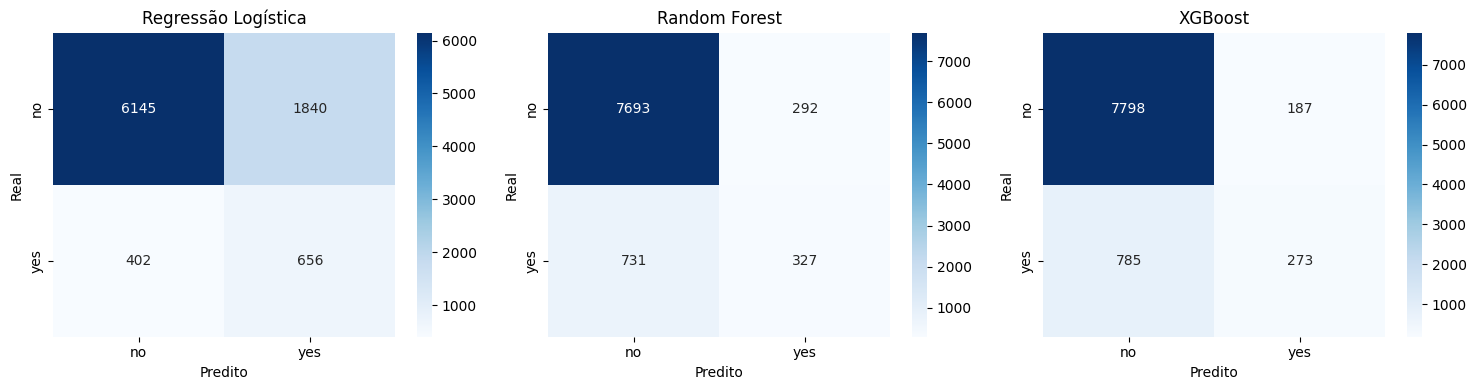

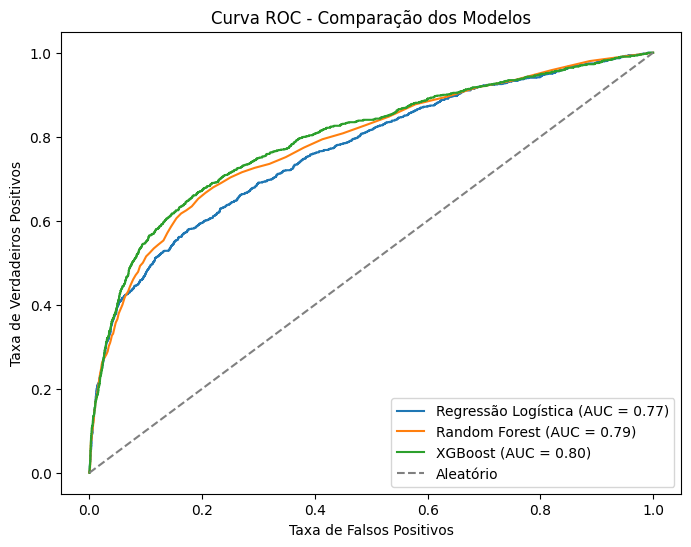

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Classification report de cada modelo
for nome, modelo in modelos.items():
    print(f"===== {nome} =====")
    print(classification_report(y_test, predicoes[nome], target_names=['no', 'yes']))
    print()

# 2. Matriz de confusão de cada modelo
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nome, modelo) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_test, predicoes[nome])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['no', 'yes'], yticklabels=['no', 'yes'])
    ax.set_title(nome)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

# 3. Curva ROC e AUC dos 3 modelos no mesmo gráfico
plt.figure(figsize=(8, 6))

for nome, modelo in modelos.items():
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nome} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Comparação dos Modelos')
plt.legend()
plt.show()

# 5.5 Separação dos Dados e Estratégia de Validação
**Responsável:** Larissa Carvalho

Para garantir uma avaliação não enviesada e refletir o desempenho real do modelo em dados não vistos:
- **Proporção da Separação:** Os dados foram divididos em **80% para Treinamento** e **20% para Teste**.
- **Estratificação (`stratify=y`):** O conjunto Bank Marketing apresenta um forte desbalanceamento no atributo-alvo `y` (aproximadamente 88% de `no` e 12% de `yes`). A estratificação foi aplicada para garantir que ambas as fatias (treino e teste) mantivessem exatamente a mesma proporção de classes do dataset original.
- **Isolamento de Teste:** O conjunto de teste foi estritamente reservado apenas para a avaliação final das métricas, evitando *data leakage* (vazamento de dados).

In [ ]:
# Importação dos modelos obrigatórios da especificação
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Reutilizando a divisão e SMOTE da Etapa 3
X_train_smote, y_train_smote = X_train_res, y_train_res

# Dicionário completo contemplando os exigidos pelo Capítulo 3 e os modelos do grupo
modelos = {
    'Baseline (Dummy)': DummyClassifier(strategy='most_frequent'),
    'SGDClassifier': SGDClassifier(random_state=42, loss='log_loss'), # Obrigatorio Cap. 3
    'Regressão Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42), # Obrigatorio Cap. 3
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# Treinamento e geração das predições no conjunto de teste
predicoes = {}
probabilidades = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train_smote, y_train_smote)
    predicoes[nome] = modelo.predict(X_test)

    # Armazenar probabilidades para a Curva ROC
    if hasattr(modelo, "predict_proba"):
        probabilidades[nome] = modelo.predict_proba(X_test)[:, 1]
    elif hasattr(modelo, "decision_function"):
        probabilidades[nome] = modelo.decision_function(X_test)

    print(f"Modelo {nome} treinado com sucesso.")

Modelo Baseline (Dummy) treinado com sucesso.
Modelo SGDClassifier treinado com sucesso.
Modelo Regressão Logística treinado com sucesso.
Modelo Random Forest treinado com sucesso.
Modelo XGBoost treinado com sucesso.


# 5.6 Modelagem e Algoritmos Utilizados
**Responsável:** Larissa Carvalho

Foram avaliados 5 modelos no total:
1. **Baseline (`DummyClassifier`):** Modelo ingênuo que sempre prevê a classe mais frequente (`no`). Serve como patamar mínimo de comparação.
2. **`SGDClassifier` (Exigência do Cap. 3):** Classificador estocástico baseado em Gradiente Descendente.
3. **`RandomForestClassifier` (Exigência do Cap. 3):** Algoritmo baseado em ensemble de árvores de decisão.
4. **Regressão Logística:** Modelo linear clássico para classificação binária.
5. **XGBoost:** Algoritmo avançado de Gradient Boosting.

=== TABELA COMPARATIVA DE DESEMPENHO ===


,Modelo,Acurácia,Precisão (Classe yes),Recall (Classe yes),F1-Score (Classe yes)
0,Baseline (Dummy),0.8830,0.0000,0.0000,0.0000
1,SGDClassifier,0.8065,0.3120,0.5425,0.3961
2,Regressão Logística,0.7521,0.2628,0.6200,0.3692
3,Random Forest,0.8869,0.5283,0.3091,0.3900
4,XGBoost,0.8925,0.5935,0.2580,0.3597



=== RELATÓRIOS DETALHADOS (CLASSIFICATION REPORT) ===

----- Baseline (Dummy) -----
              precision    recall  f1-score   support

          no       0.88      1.00      0.94      7985
         yes       0.00      0.00      0.00      1058

    accuracy                           0.88      9043
   macro avg       0.44      0.50      0.47      9043
weighted avg       0.78      0.88      0.83      9043


----- SGDClassifier -----
              precision    recall  f1-score   support

          no       0.93      0.84      0.88      7985
         yes       0.31      0.54      0.40      1058

    accuracy                           0.81      9043
   macro avg       0.62      0.69      0.64      9043
weighted avg       0.86      0.81      0.83      9043


----- Regressão Logística -----
              precision    recall  f1-score   support

          no       0.94      0.77      0.85      7985
         yes       0.26      0.62      0.37      1058

    accuracy                         

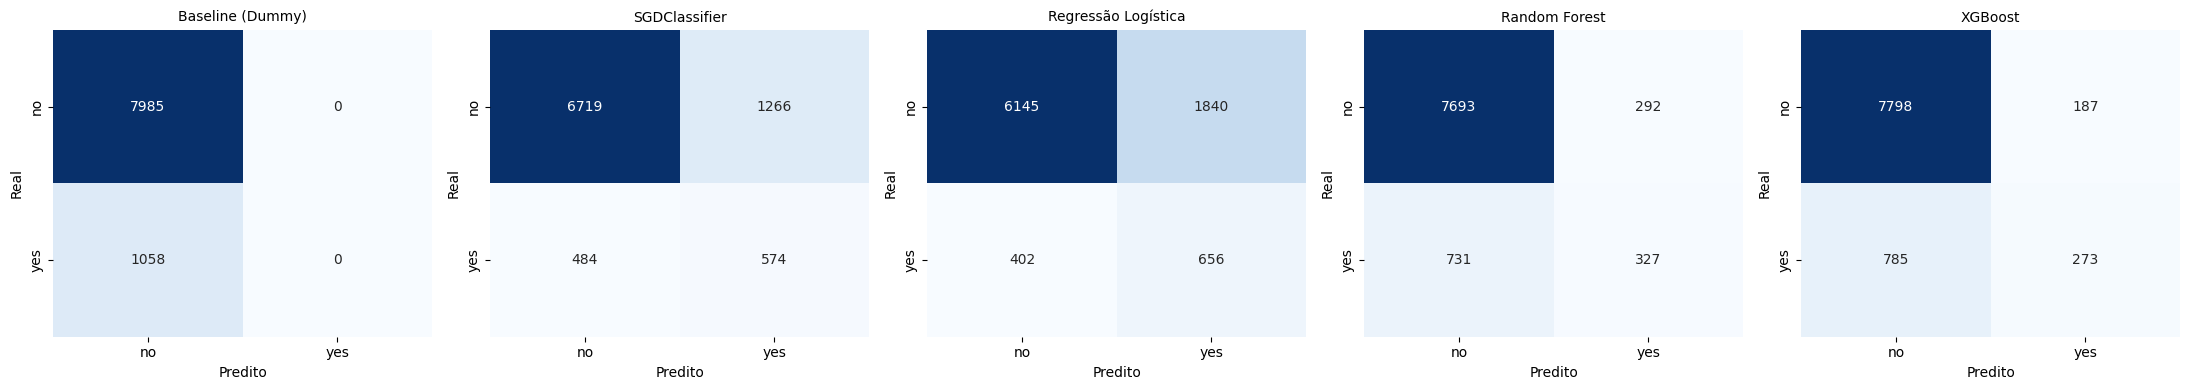

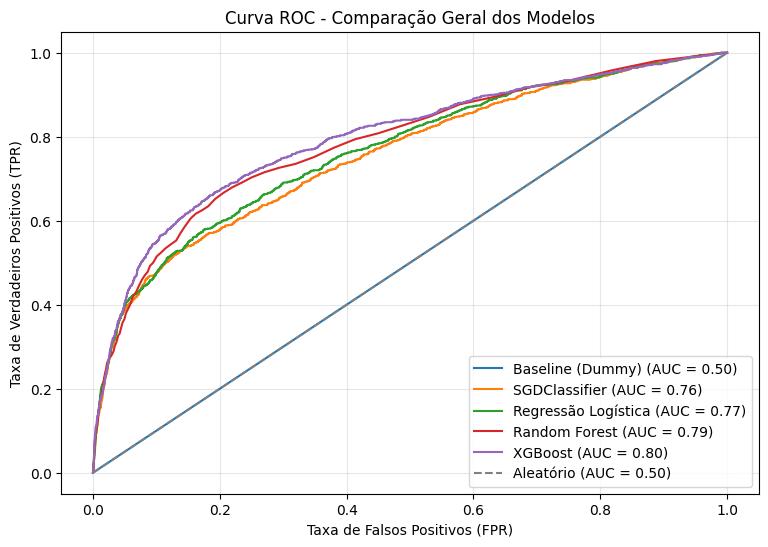

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

# 1. Tabela Consolidada de Métricas Comparativas
tabela_resultados = []

for nome in modelos.keys():
    acc = accuracy_score(y_test, predicoes[nome])
    prec = precision_score(y_test, predicoes[nome], pos_label=1, zero_division=0)
    rec = recall_score(y_test, predicoes[nome], pos_label=1, zero_division=0)
    f1 = f1_score(y_test, predicoes[nome], pos_label=1, zero_division=0)

    tabela_resultados.append({
        'Modelo': nome,
        'Acurácia': f"{acc:.4f}",
        'Precisão (Classe yes)': f"{prec:.4f}",
        'Recall (Classe yes)': f"{rec:.4f}",
        'F1-Score (Classe yes)': f"{f1:.4f}"
    })

df_resumo = pd.DataFrame(tabela_resultados)
print("=== TABELA COMPARATIVA DE DESEMPENHO ===")
display(df_resumo)

# 2. Relatórios Individuais (Classification Report)
print("\n=== RELATÓRIOS DETALHADOS (CLASSIFICATION REPORT) ===")
for nome in modelos.keys():
    print(f"\n----- {nome} -----")
    print(classification_report(y_test, predicoes[nome], target_names=['no', 'yes'], zero_division=0))

# 3. Matrizes de Confusão
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, nome in zip(axes, modelos.keys()):
    cm = confusion_matrix(y_test, predicoes[nome])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['no', 'yes'], yticklabels=['no', 'yes'], cbar=False)
    ax.set_title(nome, fontsize=10)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

# 4. Curva ROC Comparativa
plt.figure(figsize=(9, 6))

for nome in modelos.keys():
    if nome in probabilidades:
        fpr, tpr, _ = roc_curve(y_test, probabilidades[nome])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{nome} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório (AUC = 0.50)')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Comparação Geral dos Modelos')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# 5.7 Avaliação e Discussão Crítica dos Resultados
**Responsável:** Larissa Carvalho

### 1. Análise Comparativa e Escolha do Modelo Final
* **A armadilha da Acurácia:** A **Baseline (Dummy)** atinge 88,3% de acurácia apenas prevendo a classe majoritária (`no`), mas seu **Recall e F1-Score para a classe `yes` são 0.00**. Isso demonstra a ineficácia da acurácia isolada em problemas desbalanceados.
* **Modelo Indicado (Foco em Conversão de Clientes - Recall):** Se o objetivo de negócio do banco for **identificar o maior número possível de potenciais clientes para ligar**, a **Regressão Logística** apresenta o maior **Recall (0.62)** para a classe `yes`, capturando 656 de 1.058 conversões reais.
* **Modelo Indicado (Foco em Eficiência e Balanceamento - F1/AUC):** A **Random Forest** obteve o maior F1-Score (0.39) e uma excelente AUC (0.79), reduzindo significativamente o número de falsos positivos (apenas 292 contra 1.840 da Regressão Logística).

### 2. Análise dos Erros e Limitações
* **Falsos Positivos vs. Falsos Negativos:** Com o uso do SMOTE, modelos como Regressão Logística geraram mais Falsos Positivos (1.840 clientes que não gostariam do produto, mas foram classificados como interessados). Já o Random Forest gerou mais Falsos Negativos (731 clientes interessados que deixariam de ser contatados).
* **Limitação Técnica:** A remoção da variável `duration` (feita para evitar vazamento de dados) reduziu a capacidade preditiva bruta, mas garantiu a validade do experimento para uso prévio às chamadas.

### 3. Propostas de Melhorias
* Otimização de hiperparâmetros via `GridSearchCV` para o `RandomForestClassifier` e `XGBoost`.
* Teste de técnicas alternativas de balanceamento de classes (como ajuste de pesos `class_weight='balanced'`) em vez do *oversampling* sintético via SMOTE.